In [1]:
# -----------------------------
# 1. Gerekli kutuphaneler
# -----------------------------

# Veri islemleri icin pandas ve numpy
import pandas as pd
import numpy as np

# Gorsellestirme icin matplotlib ve seaborn
import matplotlib.pyplot as plt
import seaborn as sns

# Uyari mesajlarini kapatmak icin
import warnings
warnings.filterwarnings("ignore")

# Grafiklerin daha okunabilir olmasi icin stil ayari
sns.set(style="whitegrid")

# Tekrar uretilebilirlik icin random seed belirleme
np.random.seed(42)

In [2]:
# -----------------------------
# 2. Veri Seti 1: Sentetik Veri Uretimi
# -----------------------------

# Gozlem sayisi
n = 200

# Sayisal degiskenler
study_hours = np.random.normal(loc=4, scale=1.5, size=n)  # haftalik calisma saati
attendance = np.random.uniform(50, 100, n)               # devam yuzdesi
sleep_hours = np.random.normal(7, 1, n)                  # gunluk uyku suresi
internet_usage = np.random.normal(3, 1, n)               # gunluk internet kullanimi
previous_grade = np.random.normal(65, 10, n)             # onceki not ortalamasi

# Kategorik degiskenler
gender = np.random.choice(['Female', 'Male'], n)
department = np.random.choice(['Engineering', 'Social', 'Health'], n)
scholarship = np.random.choice(['Yes', 'No'], n)

# Bagimli degisken (sinav puani)
exam_score = (
    5 * study_hours +
    0.3 * attendance +
    2 * sleep_hours -
    2 * internet_usage +
    0.5 * previous_grade +
    np.random.normal(0, 5, n)
)

# Veri setini olusturma
df1 = pd.DataFrame({
    'study_hours': study_hours,
    'attendance': attendance,
    'sleep_hours': sleep_hours,
    'internet_usage': internet_usage,
    'previous_grade': previous_grade,
    'gender': gender,
    'department': department,
    'scholarship': scholarship,
    'exam_score': exam_score
})

# Ilk 5 satiri goruntuleme
print(df1.head())

   study_hours  attendance  sleep_hours  internet_usage  previous_grade  \
0     4.745071   93.868654     6.891240        3.871125       90.600845   
1     3.792604   87.038431     7.401712        2.673976       64.039401   
2     4.971533   84.850787     7.690144        4.201214       76.492733   
3     6.284545   85.124204     6.598780        2.591925       57.968236   
4     3.648770   67.974558     7.224092        0.961875       64.650115   

   gender   department scholarship  exam_score  
0    Male       Social         Yes   95.541865  
1    Male       Social         Yes   87.888474  
2  Female  Engineering         Yes  102.834595  
3    Male       Health         Yes   85.531258  
4    Male  Engineering          No   85.057626  


In [3]:
# -----------------------------
# 3. Ilk Inceleme
# -----------------------------

# Veri setinin boyutu (satir, sutun)
print("Boyut:", df1.shape)

# Degisken isimleri
print("Degiskenler:", df1.columns)

# Veri tipleri
print("\nVeri Tipleri:")
print(df1.dtypes)

# Ilk genel bilgi
print("\nGenel Bilgi:")
print(df1.info())

# Betimsel istatistikler (sayisal degiskenler)
print("\nBetimsel Istatistikler:")
print(df1.describe())

# Kategorik degiskenlerin frekansi
print("\nKategorik Degisken Dagilimi:")

for col in ['gender', 'department', 'scholarship']:
    print(f"\n{col}:")
    print(df1[col].value_counts())

Boyut: (200, 9)
Degiskenler: Index(['study_hours', 'attendance', 'sleep_hours', 'internet_usage',
       'previous_grade', 'gender', 'department', 'scholarship', 'exam_score'],
      dtype='object')

Veri Tipleri:
study_hours       float64
attendance        float64
sleep_hours       float64
internet_usage    float64
previous_grade    float64
gender             object
department         object
scholarship        object
exam_score        float64
dtype: object

Genel Bilgi:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   study_hours     200 non-null    float64
 1   attendance      200 non-null    float64
 2   sleep_hours     200 non-null    float64
 3   internet_usage  200 non-null    float64
 4   previous_grade  200 non-null    float64
 5   gender          200 non-null    object 
 6   department      200 non-null    object 
 7   scholarshi

In [4]:
# -----------------------------
# 3. Ilk Inceleme
# -----------------------------

# veri boyutu kontrolu
print("Boyut:", df1.shape)

# degisken isimleri
print("Degiskenler:", df1.columns)

# veri tipleri kontrolu
print("\nVeri Tipleri:")
print(df1.dtypes)

# genel veri bilgisi
print("\nGenel Bilgi:")
df1.info()

# sayisal degisken ozetleri
print("\nBetimsel Istatistikler:")
print(df1.describe())

# kategorik degisken dagilimi
print("\nKategorik Degisken Dagilimi:")
for col in ['gender', 'department', 'scholarship']:
    print(f"\n{col}:")
    print(df1[col].value_counts())

Boyut: (200, 9)
Degiskenler: Index(['study_hours', 'attendance', 'sleep_hours', 'internet_usage',
       'previous_grade', 'gender', 'department', 'scholarship', 'exam_score'],
      dtype='object')

Veri Tipleri:
study_hours       float64
attendance        float64
sleep_hours       float64
internet_usage    float64
previous_grade    float64
gender             object
department         object
scholarship        object
exam_score        float64
dtype: object

Genel Bilgi:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   study_hours     200 non-null    float64
 1   attendance      200 non-null    float64
 2   sleep_hours     200 non-null    float64
 3   internet_usage  200 non-null    float64
 4   previous_grade  200 non-null    float64
 5   gender          200 non-null    object 
 6   department      200 non-null    object 
 7   scholarshi

In [5]:
# -----------------------------
# 4. Eksik Veri ve Tekrar Kontrolu
# -----------------------------

# eksik veri sayisi kontrolu
print("Eksik Veri Sayisi:")
print(df1.isnull().sum())

# eksik veri orani
print("\nEksik Veri Orani (%):")
print((df1.isnull().sum() / len(df1)) * 100)

# yinelenen kayit sayisi
print("\nYinelenen Kayit Sayisi:")
print(df1.duplicated().sum())

# yinelenen kayitlari silme (varsa)
df1 = df1.drop_duplicates()

# kontrol tekrar
print("\nTemiz Veri Boyutu:", df1.shape)

Eksik Veri Sayisi:
study_hours       0
attendance        0
sleep_hours       0
internet_usage    0
previous_grade    0
gender            0
department        0
scholarship       0
exam_score        0
dtype: int64

Eksik Veri Orani (%):
study_hours       0.0
attendance        0.0
sleep_hours       0.0
internet_usage    0.0
previous_grade    0.0
gender            0.0
department        0.0
scholarship       0.0
exam_score        0.0
dtype: float64

Yinelenen Kayit Sayisi:
0

Temiz Veri Boyutu: (200, 9)


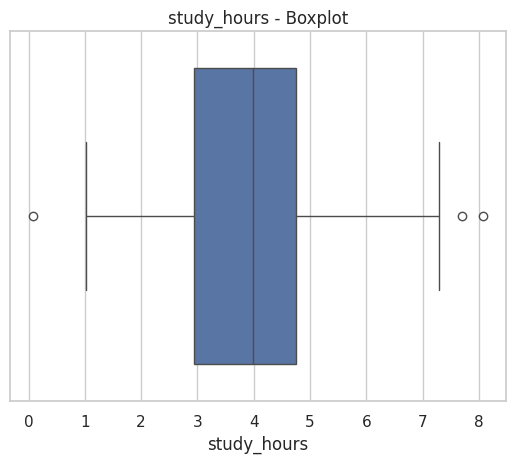

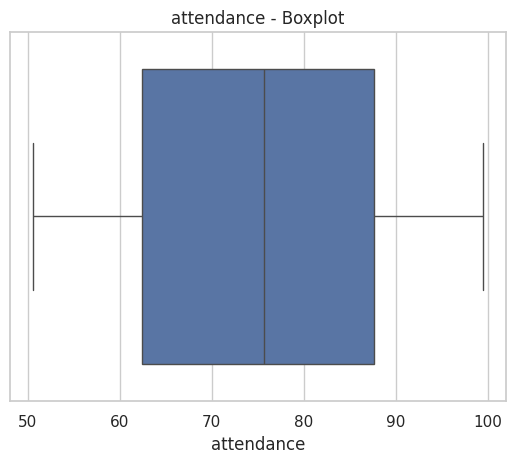

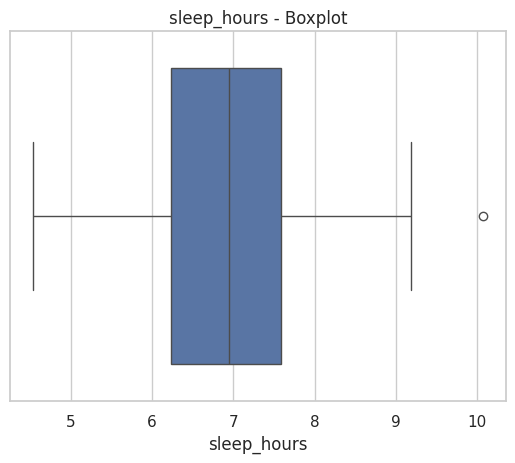

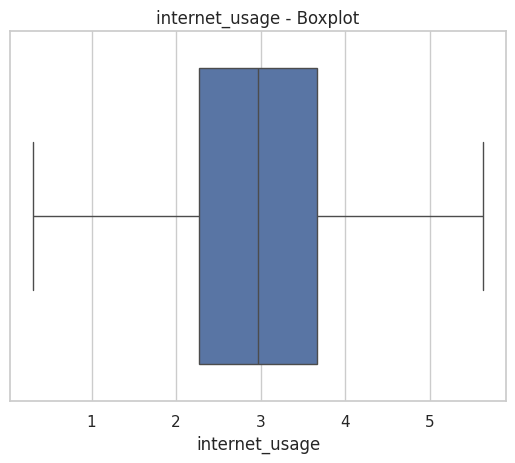

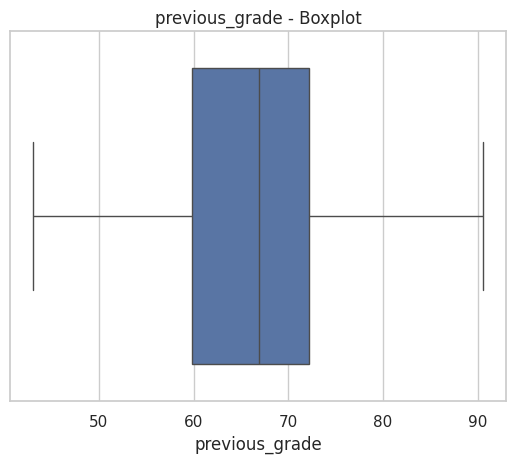

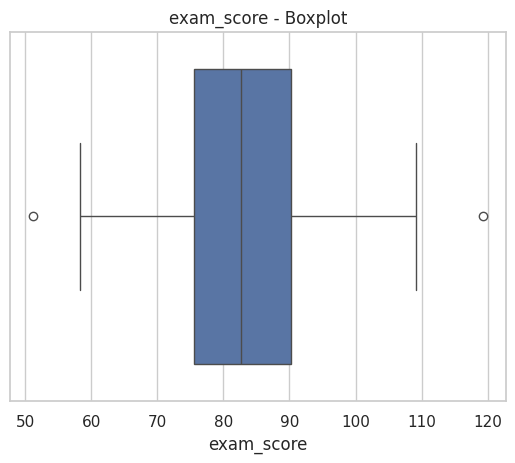

study_hours - Aykiri Deger Sayisi: 3
attendance - Aykiri Deger Sayisi: 0
sleep_hours - Aykiri Deger Sayisi: 1
internet_usage - Aykiri Deger Sayisi: 0
previous_grade - Aykiri Deger Sayisi: 0
exam_score - Aykiri Deger Sayisi: 2


In [6]:
# -----------------------------
# 5. Aykiri Deger Analizi
# -----------------------------

# sayisal degiskenleri secme
numeric_cols = df1.select_dtypes(include=np.number).columns

# boxplot ile aykiri deger gorsellestirme
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df1[col])
    plt.title(f"{col} - Boxplot")
    plt.show()

# IQR ile aykiri deger hesaplama
for col in numeric_cols:
    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df1[(df1[col] < lower_bound) | (df1[col] > upper_bound)]

    print(f"{col} - Aykiri Deger Sayisi:", outliers.shape[0])

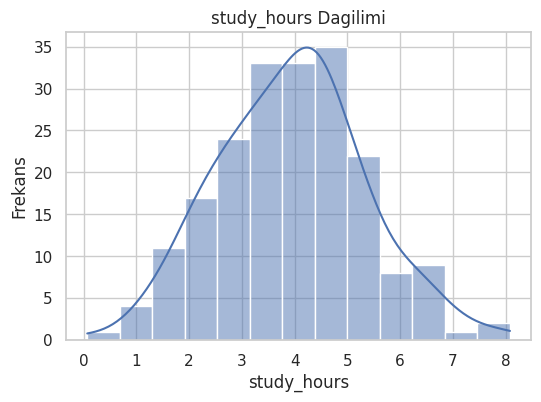

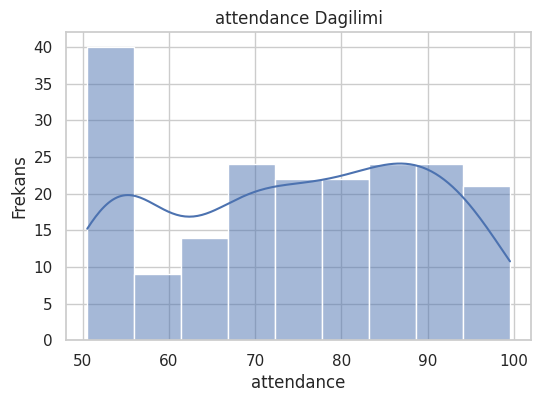

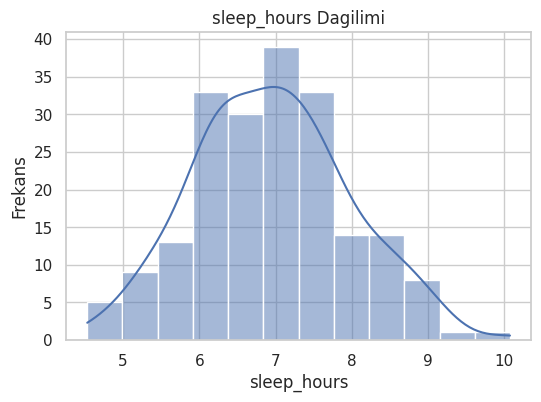

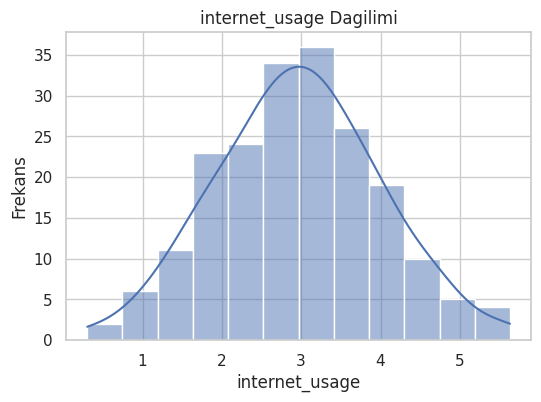

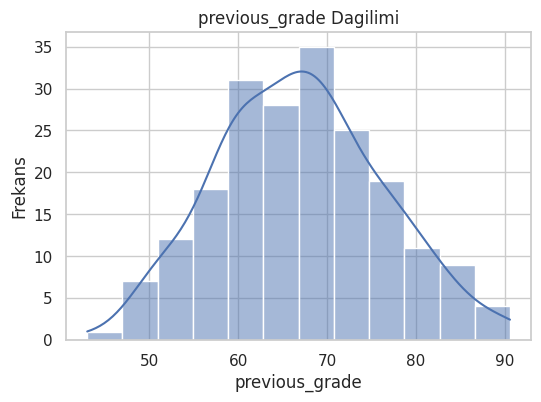

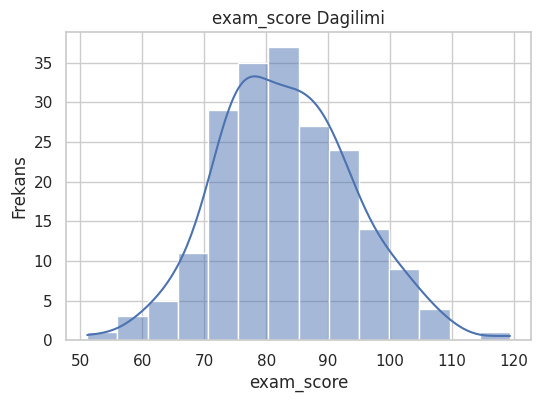

In [7]:
# -----------------------------
# 6. Dagilim Analizi - Sayisal Degiskenler
# -----------------------------

# sayisal degiskenleri secme
numeric_cols = df1.select_dtypes(include=np.number).columns

# her sayisal degisken icin histogram ve yogunluk grafigi
for col in numeric_cols:
    plt.figure(figsize=(6,4))

    sns.histplot(df1[col], kde=True)

    plt.title(f"{col} Dagilimi")
    plt.xlabel(col)
    plt.ylabel("Frekans")

    plt.show()

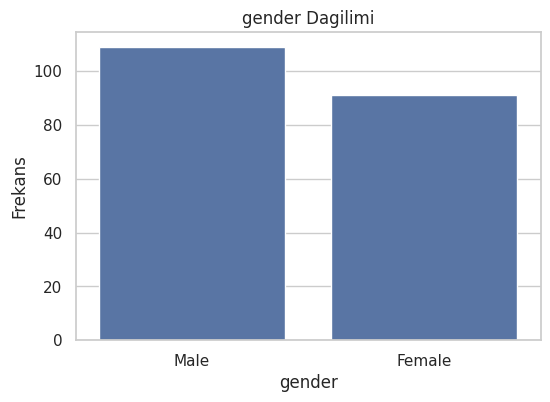

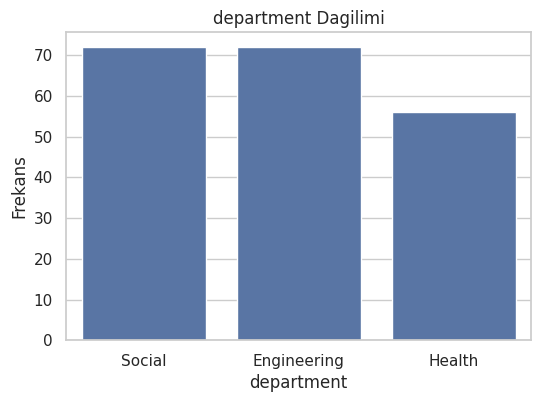

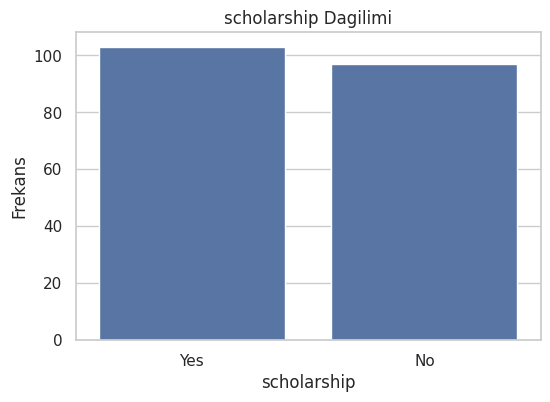

In [8]:
# -----------------------------
# 6. Dagilim Analizi - Kategorik Degiskenler
# -----------------------------

categorical_cols = ['gender', 'department', 'scholarship']

# her kategorik degisken icin bar grafigi
for col in categorical_cols:
    plt.figure(figsize=(6,4))

    sns.countplot(x=df1[col])

    plt.title(f"{col} Dagilimi")
    plt.xlabel(col)
    plt.ylabel("Frekans")

    plt.show()

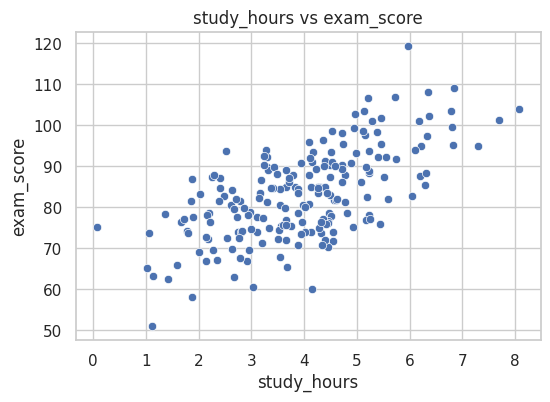

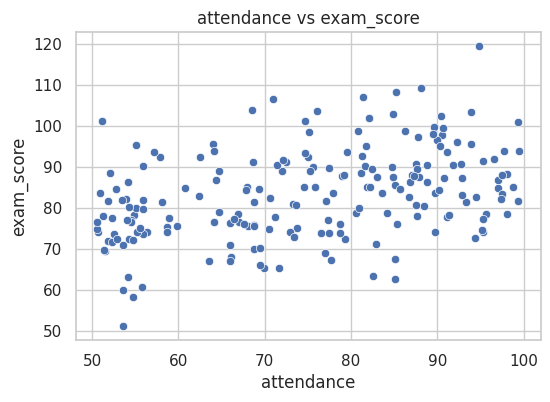

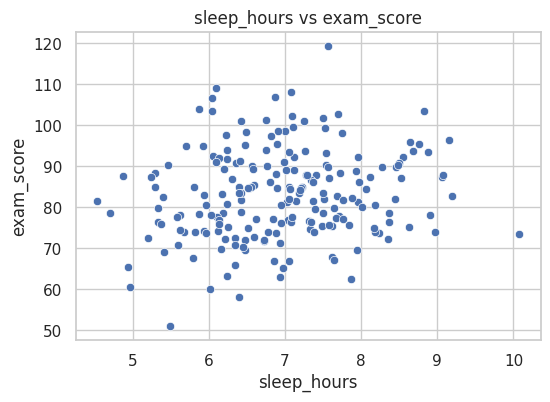

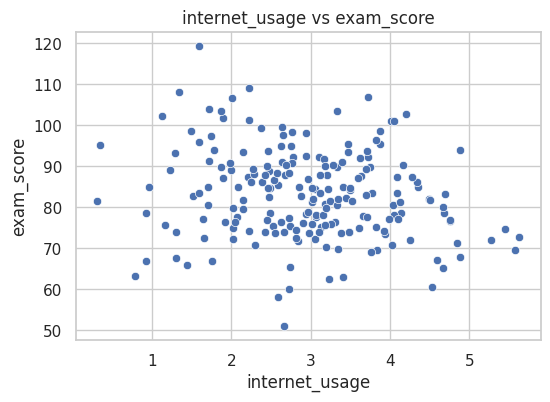

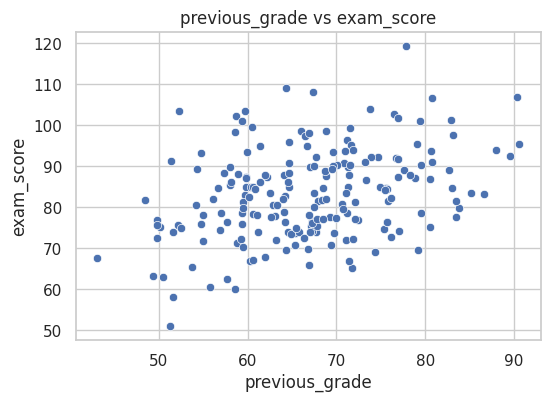

In [9]:
# -----------------------------
# 7. Iliski Analizi - Scatter Plot
# -----------------------------

# bagimli degisken ile sayisal degiskenler arasindaki iliski
for col in numeric_cols:
    if col != "exam_score":
        plt.figure(figsize=(6,4))

        sns.scatterplot(x=df1[col], y=df1["exam_score"])

        plt.title(f"{col} vs exam_score")
        plt.xlabel(col)
        plt.ylabel("exam_score")

        plt.show()

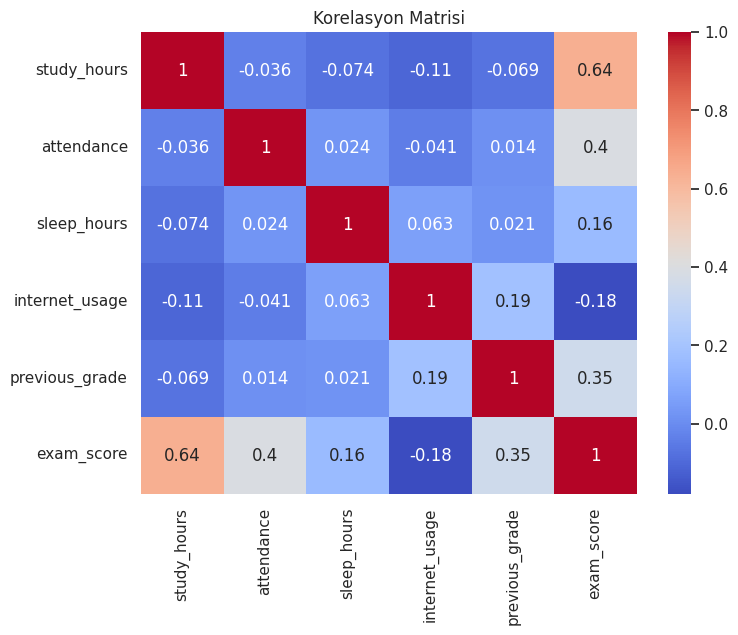

In [10]:
# -----------------------------
# 7. Korelasyon Analizi
# -----------------------------

# korelasyon matrisi hesaplama
corr_matrix = df1[numeric_cols].corr()

# heatmap ile gorsellestirme
plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

plt.title("Korelasyon Matrisi")

plt.show()

In [11]:
# -----------------------------
# 8. Veri Seti 2 - Veriyi Cekme
# -----------------------------

# veri setini URL uzerinden okuma
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df2 = pd.read_csv(url)

# ilk 5 satiri goruntuleme
print(df2.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [12]:
# -----------------------------
# 9. Veri Seti 2 - Ilk Inceleme
# -----------------------------

# veri setinin boyutu
print("Boyut:", df2.shape)

# degisken isimleri
print("\nDegiskenler:")
print(df2.columns)

# veri tipleri
print("\nVeri Tipleri:")
print(df2.dtypes)

# genel bilgi
print("\nGenel Bilgi:")
df2.info()

# sayisal degisken ozetleri
print("\nBetimsel Istatistikler:")
print(df2.describe())

# kategorik degiskenler icin ozet
print("\nKategorik Degisken Ozetleri:")
print(df2.describe(include="object"))

Boyut: (891, 12)

Degiskenler:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Veri Tipleri:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Genel Bilgi:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch    

In [13]:
# -----------------------------
# 10. Veri Seti 2 - Eksik Veri Analizi
# -----------------------------

# eksik veri sayisi
print("Eksik Veri Sayisi:")
print(df2.isnull().sum())

# eksik veri orani
print("\nEksik Veri Orani (%):")
print((df2.isnull().sum() / len(df2) * 100).round(2))

Eksik Veri Sayisi:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Eksik Veri Orani (%):
PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64


In [14]:
# -----------------------------
# 11. Veri Seti 2 - Yinelenen Kayit Kontrolu
# -----------------------------

# yinelenen kayit sayisi
print("Yinelenen Kayit Sayisi:", df2.duplicated().sum())

Yinelenen Kayit Sayisi: 0


In [15]:
# -----------------------------
# 12. Veri Seti 2 - Veri On Isleme
# -----------------------------

# PassengerId degiskeni kimlik bilgisi oldugu icin silme
if "PassengerId" in df2.columns:
    df2.drop(columns=["PassengerId"], inplace=True)

# Ticket degiskeni cok fazla benzersiz deger icerdigi icin silme
if "Ticket" in df2.columns:
    df2.drop(columns=["Ticket"], inplace=True)

# Cabin degiskeni cok fazla eksik veri icerdigi icin silme
if "Cabin" in df2.columns:
    df2.drop(columns=["Cabin"], inplace=True)

# Name degiskeni serbest metin yapisinda oldugu icin silme
if "Name" in df2.columns:
    df2.drop(columns=["Name"], inplace=True)

# Age degiskenindeki eksik degerleri ortalama ile doldurma
if "Age" in df2.columns:
    df2["Age"].fillna(df2["Age"].mean(), inplace=True)

# Embarked degiskenindeki eksik degerleri mod ile doldurma
if "Embarked" in df2.columns:
    df2["Embarked"].fillna(df2["Embarked"].mode()[0], inplace=True)

# tekrar eden kayitlari silme
df2.drop_duplicates(inplace=True)

# on isleme sonrasi kontrol
print("On Isleme Sonrasi Eksik Veri:")
print(df2.isnull().sum())

print("\nYeni Boyut:")
print(df2.shape)

On Isleme Sonrasi Eksik Veri:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Yeni Boyut:
(780, 8)


In [16]:
# -----------------------------
# 13. Veri Seti 2 - Son Kontrol
# -----------------------------

# veri tipleri tekrar kontrol
print("Veri Tipleri:")
print(df2.dtypes)

# kategorik degisken frekanslari
categorical_cols_df2 = df2.select_dtypes(exclude=np.number).columns

for col in categorical_cols_df2:
    print(f"\n{col} Frekanslari:")
    print(df2[col].value_counts())

Veri Tipleri:
Survived      int64
Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked     object
dtype: object

Sex Frekanslari:
Sex
male      488
female    292
Name: count, dtype: int64

Embarked Frekanslari:
Embarked
S    567
C    155
Q     58
Name: count, dtype: int64


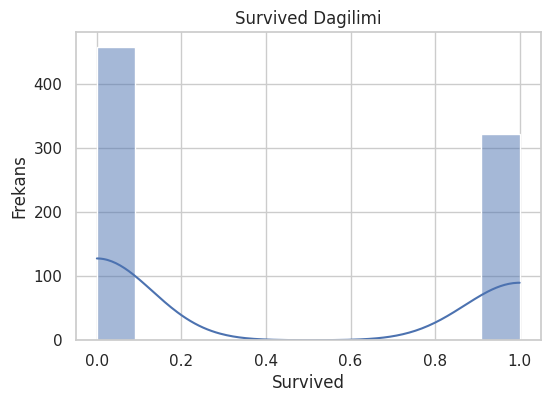

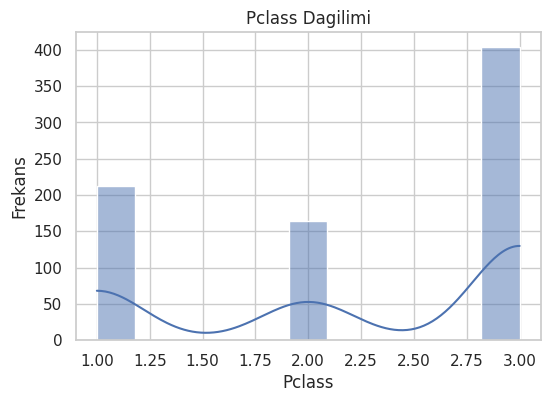

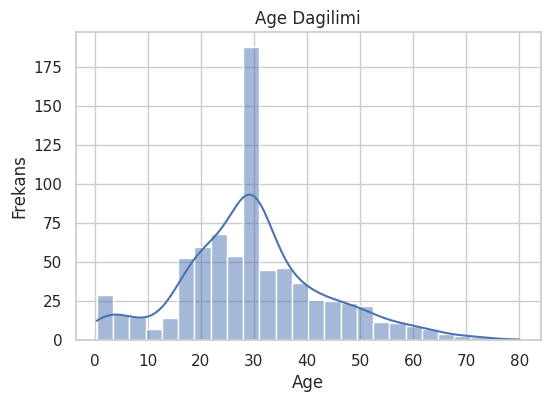

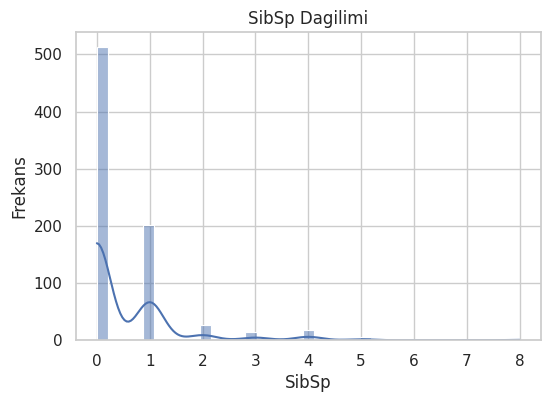

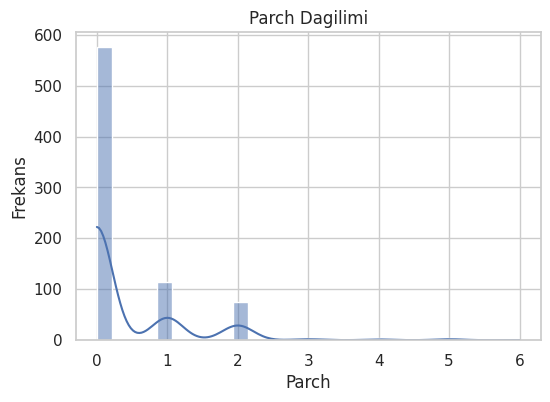

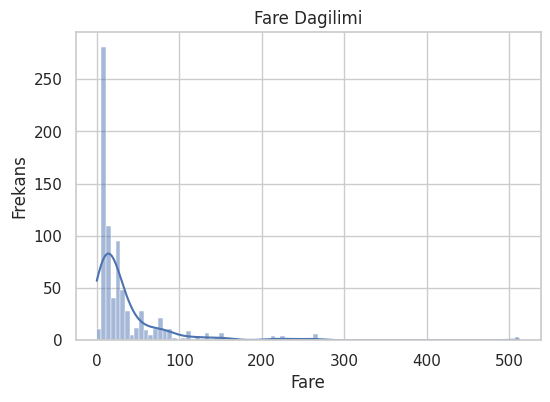

In [17]:
# -----------------------------
# 14. Veri Seti 2 - Sayisal Dagilim Analizi
# -----------------------------

# sayisal degiskenleri secme
numeric_cols_df2 = df2.select_dtypes(include=np.number).columns

# histogramlar
for col in numeric_cols_df2:
    plt.figure(figsize=(6, 4))
    sns.histplot(df2[col], kde=True)
    plt.title(f"{col} Dagilimi")
    plt.xlabel(col)
    plt.ylabel("Frekans")
    plt.show()

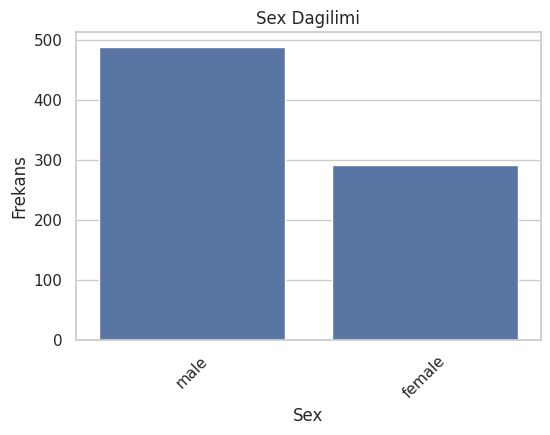

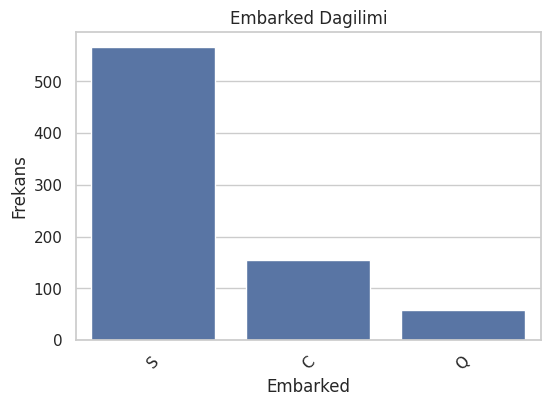

In [18]:
# -----------------------------
# 15. Veri Seti 2 - Kategorik Dagilim Analizi
# -----------------------------

# kategorik degiskenleri secme
categorical_cols_df2 = df2.select_dtypes(exclude=np.number).columns

# bar grafikler
for col in categorical_cols_df2:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=df2[col], order=df2[col].value_counts().index)
    plt.title(f"{col} Dagilimi")
    plt.xlabel(col)
    plt.ylabel("Frekans")
    plt.xticks(rotation=45)
    plt.show()

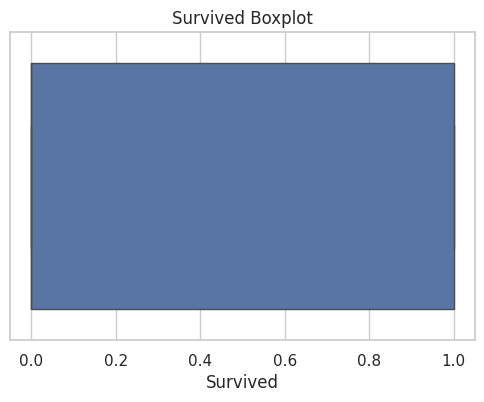

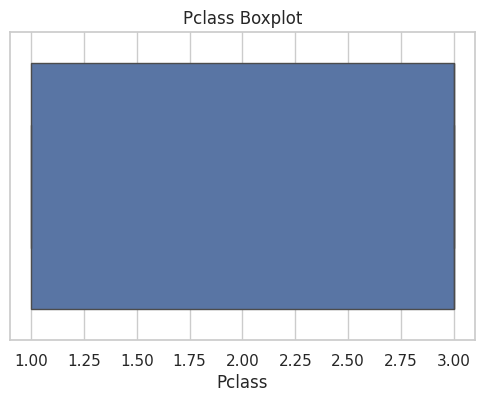

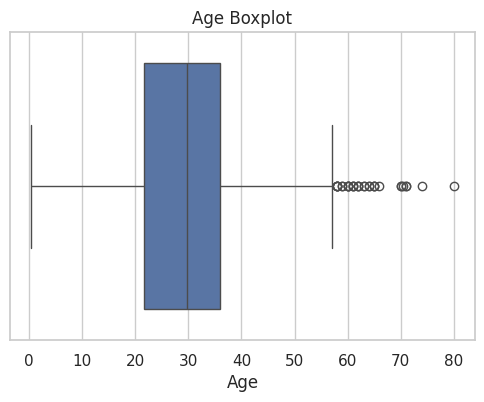

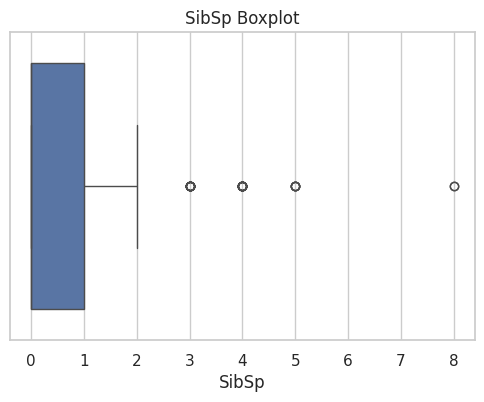

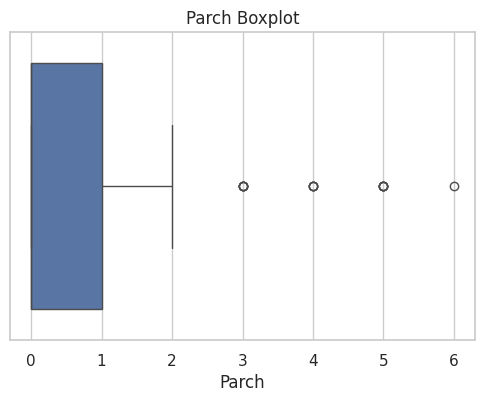

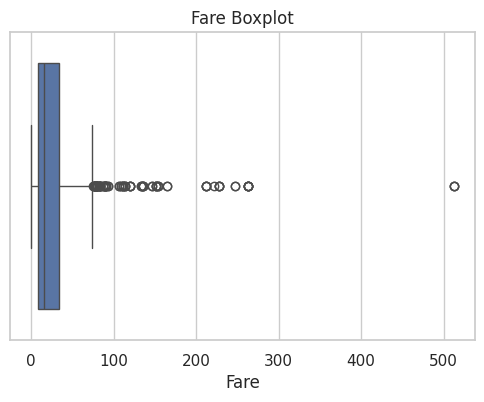

Survived - Aykiri Deger Sayisi: 0
Pclass - Aykiri Deger Sayisi: 0
Age - Aykiri Deger Sayisi: 32
SibSp - Aykiri Deger Sayisi: 39
Parch - Aykiri Deger Sayisi: 15
Fare - Aykiri Deger Sayisi: 97


In [19]:
# -----------------------------
# 16. Veri Seti 2 - Aykiri Deger Analizi
# -----------------------------

# boxplot ile aykiri deger gorsellestirme
for col in numeric_cols_df2:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df2[col])
    plt.title(f"{col} Boxplot")
    plt.xlabel(col)
    plt.show()

# IQR ile aykiri deger sayisi
for col in numeric_cols_df2:
    Q1 = df2[col].quantile(0.25)
    Q3 = df2[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df2[(df2[col] < lower_bound) | (df2[col] > upper_bound)]

    print(f"{col} - Aykiri Deger Sayisi:", outliers.shape[0])

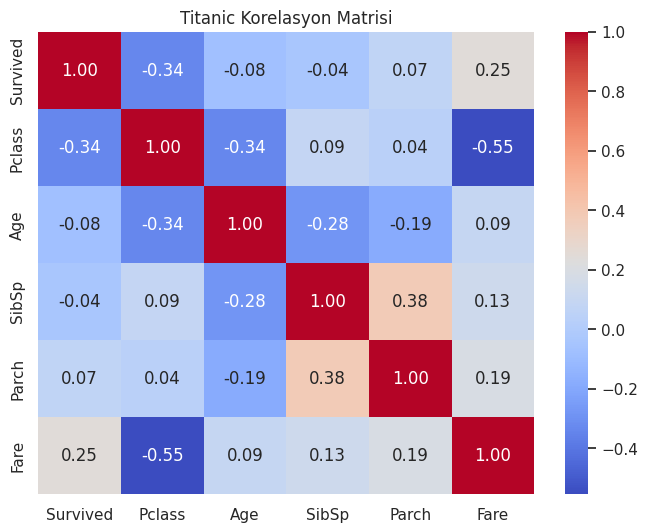

In [20]:
# -----------------------------
# 17. Veri Seti 2 - Korelasyon Analizi
# -----------------------------

# korelasyon matrisi
corr_matrix_df2 = df2[numeric_cols_df2].corr()

# heatmap ile gorsellestirme
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_df2, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Titanic Korelasyon Matrisi")
plt.show()

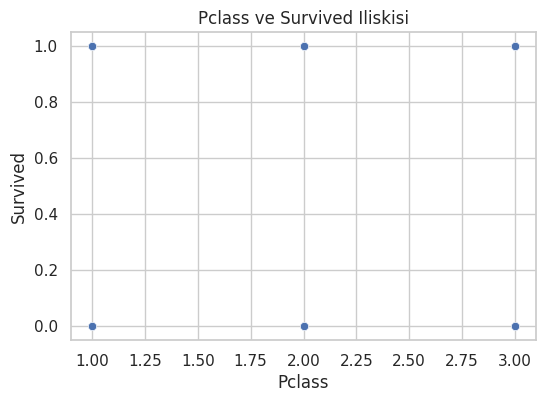

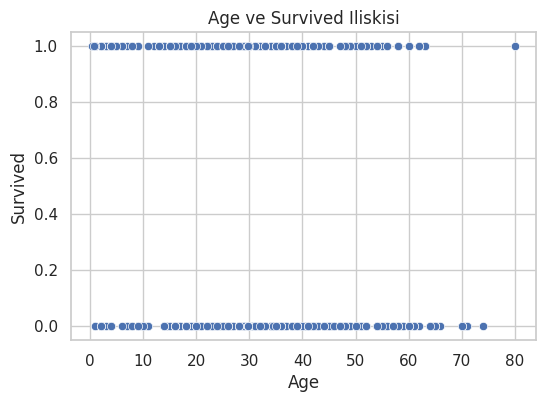

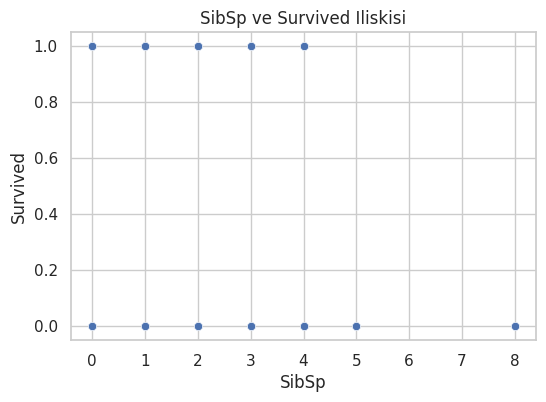

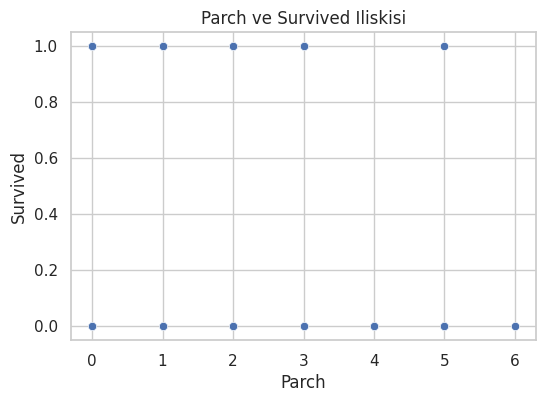

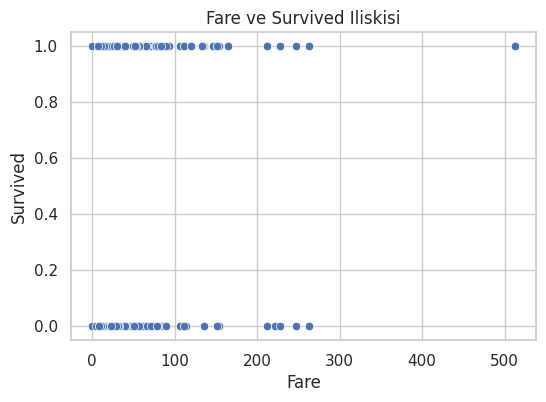

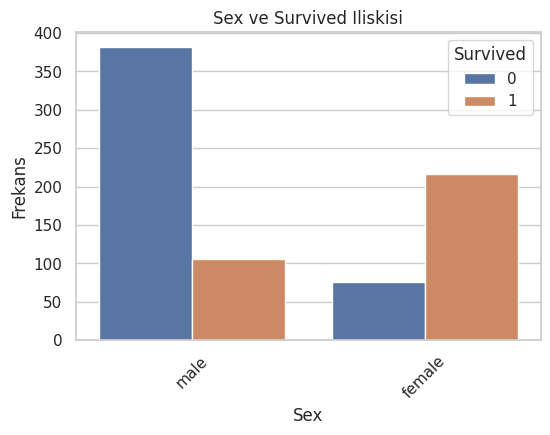

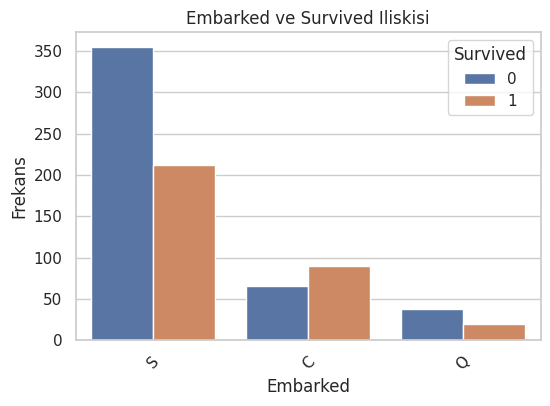

In [21]:
# -----------------------------
# 18. Veri Seti 2 - Hedef Degisken Ile Iliski
# -----------------------------

# sayisal degiskenler ile hedef degisken iliskisi
for col in numeric_cols_df2:
    if col != "Survived":
        plt.figure(figsize=(6, 4))
        sns.scatterplot(x=df2[col], y=df2["Survived"])
        plt.title(f"{col} ve Survived Iliskisi")
        plt.xlabel(col)
        plt.ylabel("Survived")
        plt.show()

# kategorik degiskenler ile hedef degisken iliskisi
for col in categorical_cols_df2:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=df2[col], hue=df2["Survived"])
    plt.title(f"{col} ve Survived Iliskisi")
    plt.xlabel(col)
    plt.ylabel("Frekans")
    plt.xticks(rotation=45)
    plt.show()